# WSJ Headline Topic Modeling & Signal Feature Extraction

**Pipeline Overview:**
1. Load & preprocess 292K+ WSJ headlines into daily corpora
2. Engineer stop-word layers (function words → headline grammar → financial meta)
3. Top-N word frequency analysis
4. LDA topic modeling with coherence-based hyperparameter tuning
5. BERTopic (or NMF fallback) for neural topic discovery
6. Word cloud visualizations + master dashboard
7. Signal map feature extraction → daily signal counts for downstream modeling

**Data:** ~292,196 headlines → 2,992 daily corpora (2018-01-01 → 2026-03-11)

---
## 0 · Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import random
import time
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot style: white background, professional colors ──
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#222222',
    'xtick.color':       '#333333',
    'ytick.color':       '#333333',
    'text.color':        '#222222',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.grid':         False,
})

# 6-color palette — high contrast on white
PALETTE6 = ['#1b6fa8', '#d63e2a', '#2ca02c', '#e6850e', '#8b5cc2', '#c4446f']
# Extended palette for larger grids
PALETTE12 = PALETTE6 + ['#17becf', '#bcbd22', '#7f7f7f', '#e377c2', '#ff7f0e', '#2ca02c']

DPI = 300   # publication-quality

print('All imports loaded.')

All imports loaded.


---
## 1 · Load Data & Build Daily Corpora

In [2]:
raw = pd.read_csv('wsj_headlines.csv', encoding='utf-8')
raw['date'] = pd.to_datetime(raw['date'])
raw['headline'] = raw['headline'].astype(str).str.strip()

# One row per date: all headlines concatenated with period separator
daily = (
    raw.sort_values(['date', 'timestamp'])
    .groupby('date')['headline']
    .agg(lambda x: ' . '.join(x))
    .rename('corpus')
    .to_frame()
)
daily['corpus_lower'] = daily['corpus'].str.lower()

print(f'{len(raw):,} headlines → {len(daily):,} daily corpora')
print(f'Date range: {daily.index.min().date()} → {daily.index.max().date()}')
print(f'Avg headlines/day: {len(raw)/len(daily):.1f}')

292,196 headlines → 2,992 daily corpora
Date range: 2018-01-01 → 2026-03-11
Avg headlines/day: 97.7


In [3]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2992 entries, 2018-01-01 to 2026-03-11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   corpus        2992 non-null   object
 1   corpus_lower  2992 non-null   object
dtypes: object(2)
memory usage: 70.1+ KB


---
## Stop-Word Engineering & Text Cleaning

**Three-layer stop-word strategy:**
- **Layer 1:** Standard English function words (safe to always remove)
- **Layer 2:** WSJ headline grammar — verbs of attribution, generic motion verbs, temporal/positional adverbs
- **Layer 3:** Financial meta — titles, calendar words, magnitude terms, structural nouns, newsroom meta

**Key design decisions:**
- Words like `bank`, `market`, `stock`, `trade`, `oil`, `fed` are **NOT** stop words — they carry signal
- Bigram-capable keywords in the signal map (e.g., `rate cut`, `trade war`) are preserved as unigrams here; the signal map uses regex matching on raw text later
- We keep tokens with `len > 2` to drop artifacts like `st`, `nd`, `mr`

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# LAYER 1 — Standard English function words
# ─────────────────────────────────────────────────────────────────────────────
_LAYER1 = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with','by',
    'from','up','about','into','through','during','is','are','was','were','be',
    'been','being','have','has','had','do','does','did','will','would','could',
    'should','may','might','shall','can','need','he','she','it','they','we',
    'you','i','me','him','her','them','us','my','your','his','its','their',
    'our','this','that','these','those','which','who','what','when','where',
    'why','how','all','both','each','few','more','most','other','some','such',
    'no','not','only','same','so','than','too','very','just','also','as','if',
    'then','there','here','s','t','re','ve','ll','d','one','two','three',
    'don','doesn','didn','won','wouldn','couldn','shouldn','isn','aren',
    'wasn','weren','hasn','haven','hadn',
}

# ─────────────────────────────────────────────────────────────────────────────
# LAYER 2 — WSJ headline grammar / boilerplate verbs & connectors
# ─────────────────────────────────────────────────────────────────────────────
_LAYER2 = {
    # Prepositions / connectors
    'after','before','over','under','off','out','back','down','ahead',
    'since','amid','near','within','across','beyond','against','around',
    'without','throughout','despite','following','while','ago',

    # Attribution / reporting verbs
    'says','said','say','tells','told','ask','asked','wants','wanted',
    'sees','seen','show','shows','showed','report','reports','reported',

    # Generic motion / state-change verbs (no directional signal)
    'hit','hits','set','sets','rise','rises','rose','risen',
    'fall','falls','fell','fallen','cut','cuts','push','pushes',
    'get','gets','got','make','makes','made','take','takes','took','taken',
    'give','gives','gave','given','come','comes','came',
    'keep','keeps','kept','call','calls','called','face','faces','faced',
    'hold','holds','held','move','moves','moved','turn','turns','turned',
    'look','looks','looked','find','finds','found','seek','seeks','sought',
    'plan','plans','planned','agree','agrees','agreed',
    'warn','warns','warned','raise','raises','raised',
    'draw','draws','drew','drawn','run','runs','ran','put','puts','led','lead',
    'add','adds','added','bring','brings','brought','leave','leaves','left',
    'try','tries','tried','start','starts','started','end','ends','ended',
    'open','opens','opened','close','closes','closed','help','helps','helped',
    'pay','pays','paid','buy','buys','bought','sell','sells','sold',
    'go','goes','went','gone','work','works','worked',

    # Temporal / positional adverbs
    'now','still','already','soon','later','once','even','just','yet',
    'ever','never','often','always','however','meanwhile','again','instead',

    # Generic adjectives
    'further','former','latest','first','last','next',
    'new','old','big','high','low','long','short','top','key','major',
    'main','own','full','wide','hard','likely','early',

    # Abbreviations
    'per','vs','via','et','non','co','inc','llc','corp','ltd','plc',
}

# ─────────────────────────────────────────────────────────────────────────────
# LAYER 3 — Financial meta / structural words
# NOTE: Signal words (bank, market, stock, trade, oil, etc.) are NOT here
# ─────────────────────────────────────────────────────────────────────────────
_LAYER3 = {
    # Corporate titles
    'ceo','cfo','coo','cto','cio','chairman','president','director','founder',
    'executive','officer','head','chief','vice','managing','general','senior',

    # Generic containers
    'company','companies','firm','firms','group','groups','unit','units',
    'business','businesses','industry','industries',

    # Calendar words
    'annual','year','years','month','months','week','weeks',
    'day','days','time','times','today','quarter','quarterly',
    'monday','tuesday','wednesday','thursday','friday','saturday','sunday',
    'january','february','march','april','june','july','august',
    'september','october','november','december',
    'half','fiscal',

    # Magnitude / scale
    'billion','million','trillion','percent','pct',

    # Structural nouns (no directional signal)
    'move','moves','bid','bids','talk','talks','step','steps',
    'way','ways','part','parts','case','cases','use','uses',
    'side','term','terms','number','numbers','point','points','record',
    'level','levels','rate','rates','price','prices','share','shares',
    'deal','deals','data','growth','change','changes','value','cost','costs',
    'issue','issues','state','states','world','global','country','countries',
    'government','official','officials','people','public','according',
    'report','review','program','system','service','services',

    # Newsroom meta
    'roundup','analysis','update','video','brief','opinion','editorial',
    'exclusive','breaking','live','watch','read','listen','subscribe',
    'newsletter','podcast','wsj','wall','street','journal',
}

STOP_WORDS = _LAYER1 | _LAYER2 | _LAYER3

print(f'Stop-word layers: L1={len(_LAYER1)}, L2={len(_LAYER2)}, L3={len(_LAYER3)}')
print(f'Total unique stop words: {len(STOP_WORDS)}')

Stop-word layers: L1=118, L2=217, L3=149
Total unique stop words: 480


In [5]:
def clean_tokens(text):
    """Lowercase, strip non-alpha, remove stop words, min length 3."""
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    return [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]


df = daily.copy()
full_corpus = ' '.join(df['corpus_lower'].tolist())
all_tokens  = clean_tokens(full_corpus)
df['clean_text'] = df['corpus_lower'].apply(lambda x: ' '.join(clean_tokens(x)))

word_freq = Counter(all_tokens)

print(f'DataFrame: {df.shape[0]:,} rows | {df.index.min().date()} → {df.index.max().date()}')
print(f'Clean tokens: {len(all_tokens):,}  |  Unique: {len(set(all_tokens)):,}')
print(f'\nTop 20 words: {[w for w, _ in word_freq.most_common(20)]}')

DataFrame: 2,992 rows | 2018-01-01 → 2026-03-11
Clean tokens: 1,541,208  |  Unique: 56,015

Top 20 words: ['trump', 'china', 'market', 'biden', 'covid', 'fed', 'coronavirus', 'york', 'home', 'stocks', 'ukraine', 'oil', 'russia', 'trade', 'tech', 'court', 'house', 'bank', 'war', 'investors']


---
## Top-50 Word Frequency

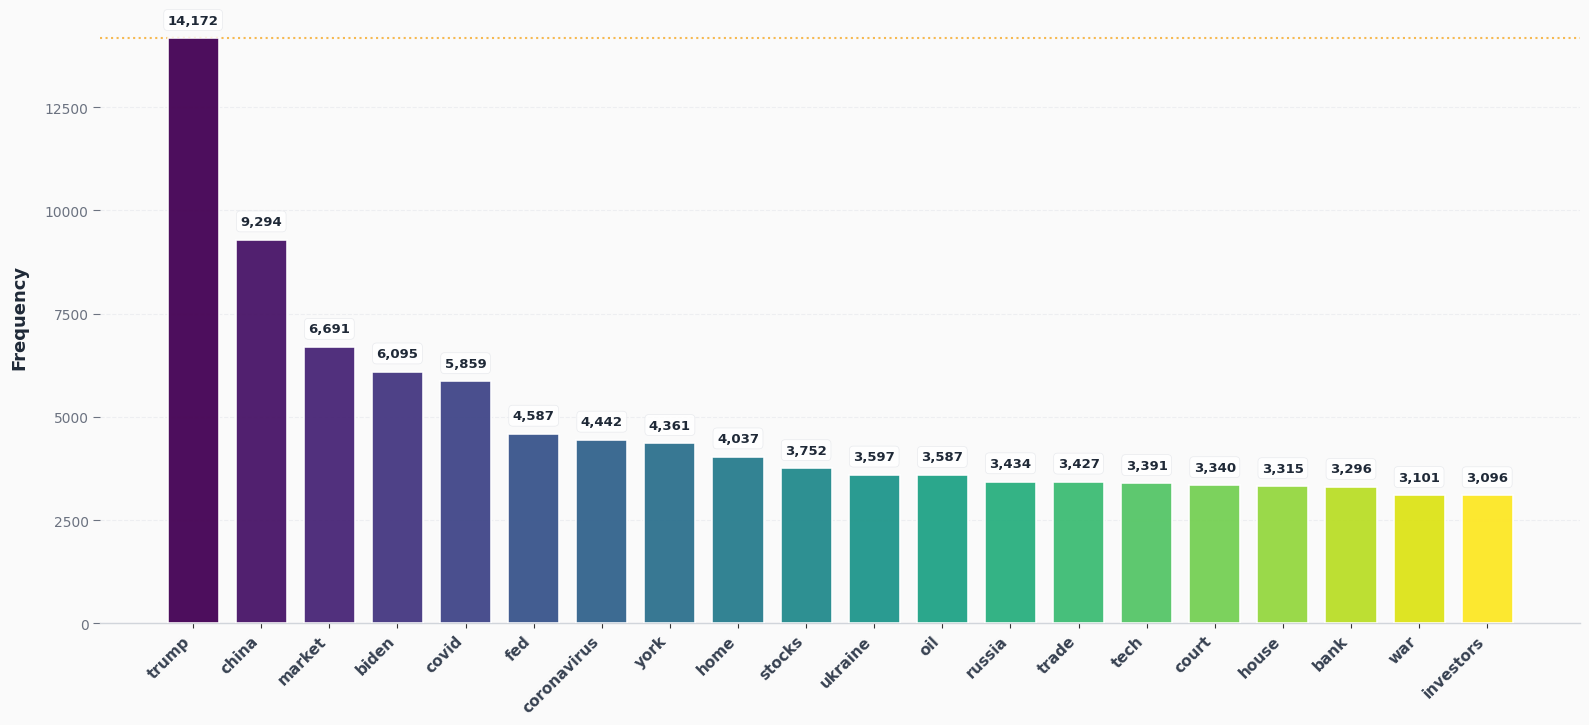

✓ Saved: 01_top20_word_frequency.png


In [6]:
# ── Top 20 Most Frequent Words ──────────────────────────────────────
top20 = word_freq.most_common(20)
w20, c20 = zip(*top20)

# Create figure with elegant styling
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#FAFAFA')  # Soft off-white background
ax.set_facecolor('#FAFAFA')

# Use matplotlib's built-in 'cool' colormap (magenta → cyan)
cmap = plt.cm.viridis
grad = [cmap(v) for v in np.linspace(0.0, 1.0, 20)]

# Create bars with clean styling
bars = ax.bar(np.arange(20), c20, 
              color=grad, 
              edgecolor='#FFFFFF',
              linewidth=1.2, 
              width=0.75, 
              zorder=3,
              alpha=0.95)

# Elegant horizontal gridlines (subtle & refined)
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(axis='y', color='#E5E7EB', linewidth=0.8, linestyle='--', 
        zorder=0, alpha=0.6)

# X-axis labels with better readability
ax.set_xticks(np.arange(20))
ax.set_xticklabels(w20, fontsize=11, rotation=45, ha='right',
                   fontweight='semibold', color='#374151',
                   fontfamily='sans-serif')

# Y-axis with clean styling
ax.set_ylabel('Frequency', fontsize=13, fontweight='bold', labelpad=12,
              color='#1F2937', fontfamily='sans-serif')
ax.tick_params(axis='y', labelsize=10, colors='#6B7280', 
               direction='out', length=5, width=0.8)

# # Title with hierarchy & visual appeal
# ax.set_title('Top 20 Most Frequent Words in WSJ Headlines',
#              fontsize=18, fontweight='bold', color='#111827', 
#              pad=25, loc='left', fontfamily='sans-serif')

# Clean spine styling (minimalist approach)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#D1D5DB')
ax.spines['bottom'].set_linewidth(1.0)

# Count labels with elegant styling & background highlight
for i, (bar, cnt) in enumerate(zip(bars, c20)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            cnt + max(c20) * 0.02,
            f'{cnt:,}', 
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', 
            color='#1F2937',
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='#FFFFFF', 
                     edgecolor='#E5E7EB',
                     alpha=0.85, linewidth=0.5))

# Add subtle horizontal reference line at max value
ax.axhline(y=max(c20), color='#F59E0B', linewidth=1.5, 
           linestyle=':', alpha=0.7, zorder=1)

# Adjust layout for optimal spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('01_top20_word_frequency.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='#FAFAFA', 
            edgecolor='none')
plt.show()
print('✓ Saved: 01_top20_word_frequency.png')

---
## LDA Topic Modeling with Coherence Tuning

**Improvements over original code:**
- `max_df=0.80` instead of 0.90 — drops words appearing in >80% of docs (too generic)
- `min_df=5` — need at least 5 occurrences for stability with 3K docs
- `max_iter=50` — better convergence (original had 30)
- Grid search over `n_components` ∈ {4, 6, 8, 10, 12} using perplexity + log-likelihood
- Final model uses best `n_components`

In [ ]:
random.seed(time.time())
# ── Vectorize for LDA ──
cv = CountVectorizer(
    max_df=0.80,          # drop words in >80% of docs (too generic for topics)
    min_df=5,             # need ≥5 occurrences for stability
    max_features=3000,    # richer vocab for 3K docs
)
dtm = cv.fit_transform(df['clean_text'])
vocab = np.array(cv.get_feature_names_out())

print(f'Document-term matrix: {dtm.shape[0]:,} docs × {dtm.shape[1]:,} terms')
print(f'Non-zero entries: {dtm.nnz:,} ({dtm.nnz / (dtm.shape[0]*dtm.shape[1])*100:.2f}% density)')

Document-term matrix: 2,992 docs × 3,000 terms
Non-zero entries: 848,725 (9.46% density)


In [ ]:
random.seed(time.time())
# ── Grid search: find best n_topics via perplexity & log-likelihood ──
K_RANGE = [4, 6, 8, 10, 12]
results = []

for k in K_RANGE:
    lda_tmp = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=50,
        learning_method='online',
        batch_size=256,
        doc_topic_prior=max(0.1, 1.0 / k),  # alpha: sparser with more topics
        topic_word_prior=0.01,               # beta: encourage focused topics
    )
    lda_tmp.fit(dtm)
    perp = lda_tmp.perplexity(dtm)
    ll   = lda_tmp.score(dtm)
    results.append({'k': k, 'perplexity': perp, 'log_likelihood': ll})
    print(f'  k={k:2d}  |  perplexity={perp:,.1f}  |  log-likelihood={ll:,.1f}')

res_df = pd.DataFrame(results)

  k= 4  |  perplexity=1,928.1  |  log-likelihood=-7,972,226.5
  k= 6  |  perplexity=1,953.9  |  log-likelihood=-7,986,226.1
  k= 8  |  perplexity=1,961.0  |  log-likelihood=-7,990,068.1
  k=10  |  perplexity=1,967.0  |  log-likelihood=-7,993,306.6
  k=12  |  perplexity=1,969.8  |  log-likelihood=-7,994,779.8


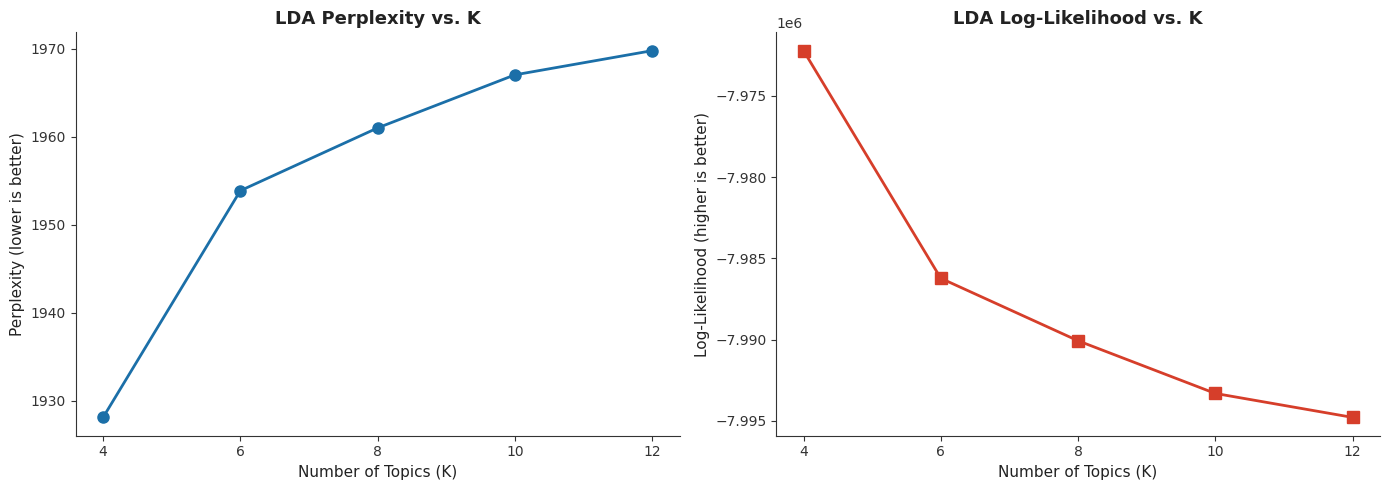

Saved: 02_lda_tuning.png


In [9]:
# ── Plot: Perplexity & Log-Likelihood vs. K ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(res_df['k'], res_df['perplexity'], 'o-', color=PALETTE6[0], lw=2, markersize=8)
ax1.set_xlabel('Number of Topics (K)', fontsize=11)
ax1.set_ylabel('Perplexity (lower is better)', fontsize=11)
ax1.set_title('LDA Perplexity vs. K', fontsize=13, fontweight='bold')
ax1.set_xticks(K_RANGE)
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(res_df['k'], res_df['log_likelihood'], 's-', color=PALETTE6[1], lw=2, markersize=8)
ax2.set_xlabel('Number of Topics (K)', fontsize=11)
ax2.set_ylabel('Log-Likelihood (higher is better)', fontsize=11)
ax2.set_title('LDA Log-Likelihood vs. K', fontsize=13, fontweight='bold')
ax2.set_xticks(K_RANGE)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('02_lda_tuning.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: 02_lda_tuning.png')

In [ ]:
random.seed(time.time())
# ── Select best K (lowest perplexity) and refit ──
# NOTE: You can manually override BEST_K if domain knowledge suggests otherwise.
# For financial news with your signal map (13 categories), K=8-10 is often a good fit.
BEST_K = int(res_df.loc[res_df['perplexity'].idxmin(), 'k'])
print(f'Best K by perplexity: {BEST_K}')

# Override if you want to align closer to your signal map categories
# BEST_K = 8  # uncomment to override

N_TOPICS = BEST_K

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=50,
    learning_method='online',
    batch_size=256,
    doc_topic_prior=max(0.1, 1.0 / N_TOPICS),
    topic_word_prior=0.01,
)
lda.fit(dtm)


def get_topics(model, feat_names, n=14):
    """Extract top-n words per topic from a fitted topic model."""
    return {
        i: [(feat_names[j], comp[j]) for j in comp.argsort()[:-n-1:-1]]
        for i, comp in enumerate(model.components_)
    }


def get_topics_for_cloud(model, feat_names, n=50):
    """Extract top-n words per topic — larger n for richer word clouds."""
    return {
        i: [(feat_names[j], comp[j]) for j in comp.argsort()[:-n-1:-1]]
        for i, comp in enumerate(model.components_)
    }


lda_topics = get_topics(lda, vocab)
lda_topics_cloud = get_topics_for_cloud(lda, vocab, n=50)  # richer set for word clouds

print(f'\n── LDA Topics (K={N_TOPICS}) ──')
for tid, wws in lda_topics.items():
    print(f'  Topic {tid+1}: {" | ".join(w for w, _ in wws[:10])}')

Best K by perplexity: 4

── LDA Topics (K=4) ──
  Topic 1: fed | trade | york | bank | stocks | investors | oil | fund | capital | house
  Topic 2: ukraine | biden | russia | war | israel | inflation | russian | home | america | court
  Topic 3: covid | coronavirus | biden | york | pandemic | home | vaccine | market | stock | city
  Topic 4: market | profit | sales | tariffs | oil | trade | tariff | revenue | higher | tech


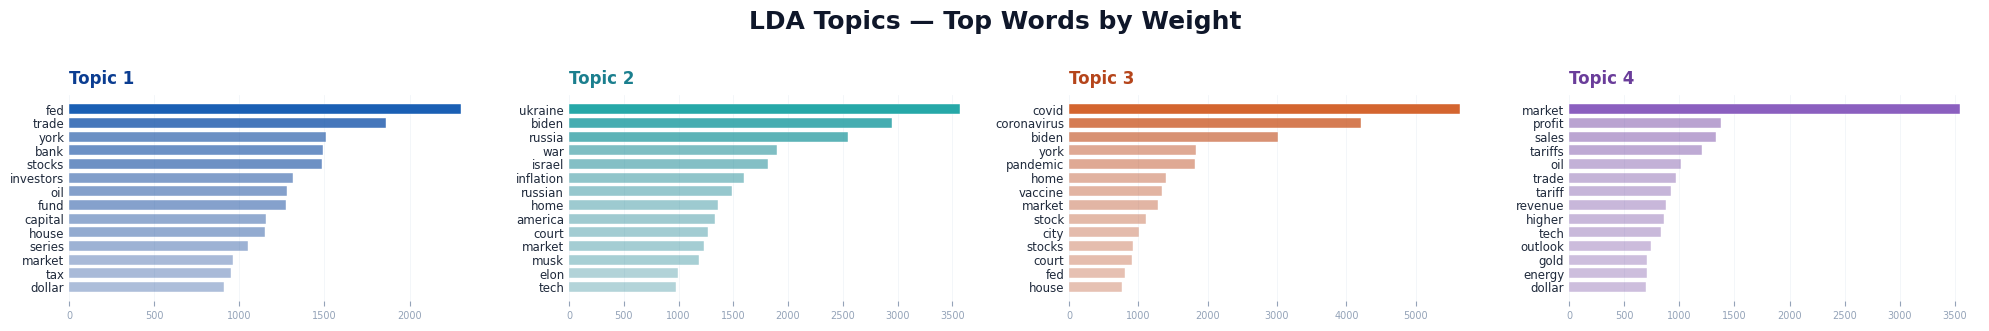

Saved: 02_lda_topic_top_words.png


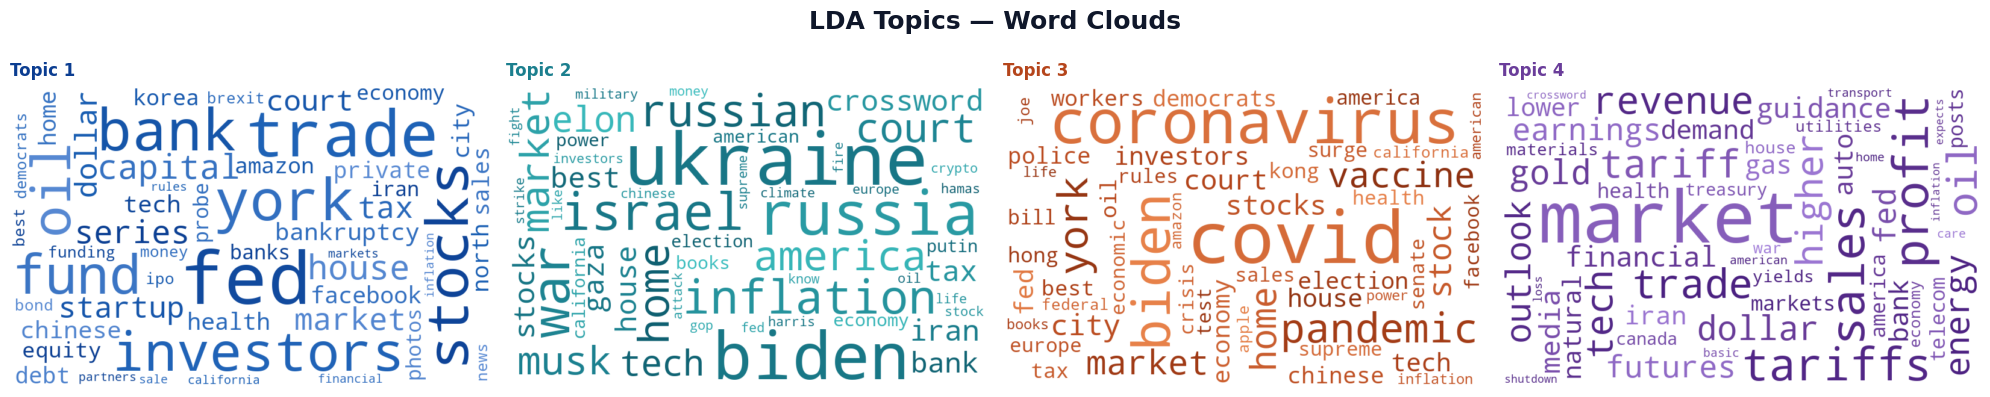

Saved: 03_lda_topic_wordclouds.png


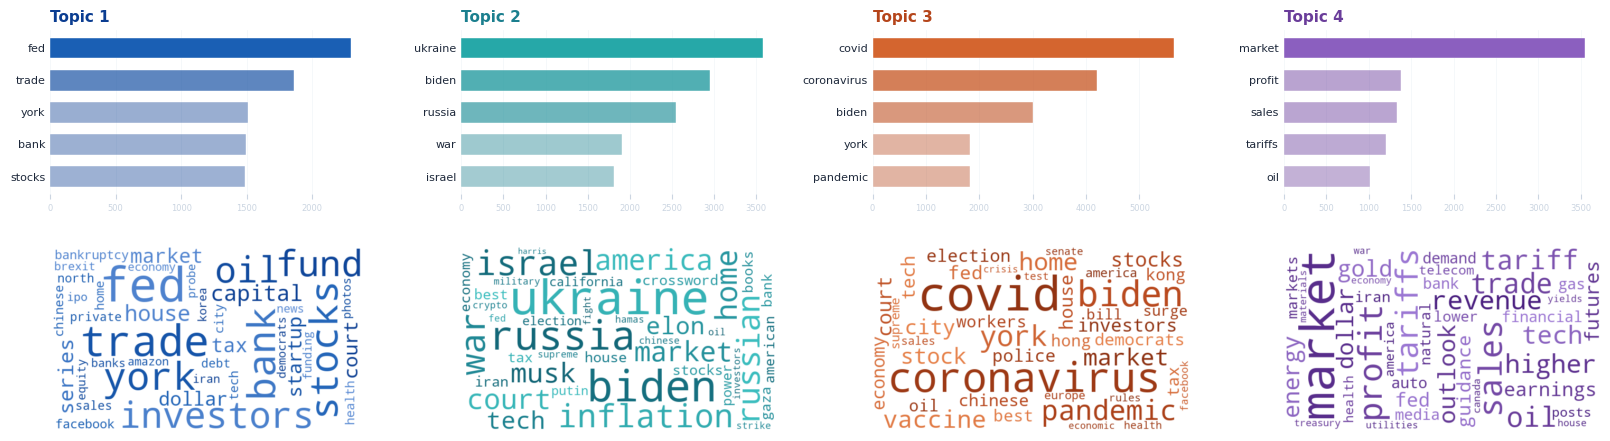

Saved: 04_lda_topic_summary.png


In [11]:
"""
LDA Topic Visualization — Beautiful Bar Charts + Word Clouds
=============================================================
Drop this code right after your LDA fitting block.
Requires: matplotlib, numpy, wordcloud

    pip install matplotlib numpy wordcloud
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap

DPI = 300

# ── Color palettes (one per topic, all high-contrast on white) ──────
TOPIC_PALETTES = [
    ['#0B3D91', '#1A5FB4'],   # Deep blue
    ['#1B7F8E', '#26A8A8'],   # Teal
    ['#B5451B', '#D4652F'],   # Burnt orange
    ['#6A3D9A', '#8B5FBF'],   # Purple
    ['#2E7D32', '#43A047'],   # Forest green
    ['#C62828', '#E53935'],   # Crimson
    ['#00695C', '#00897B'],   # Dark teal
    ['#4527A0', '#5E35B1'],   # Indigo
    ['#AD6800', '#D48A00'],   # Gold
    ['#37474F', '#546E7A'],   # Slate
    ['#880E4F', '#AD1457'],   # Magenta
    ['#1565C0', '#1E88E5'],   # Royal blue
    ['#558B2F', '#7CB342'],   # Olive green
    ['#BF360C', '#E64A19'],   # Deep orange
    ['#283593', '#3949AB'],   # Navy indigo
]

# WordCloud colormaps matching each topic
WC_CMAPS = [
    LinearSegmentedColormap.from_list('', ['#0B3D91', '#1A5FB4', '#5B8BD4']),
    LinearSegmentedColormap.from_list('', ['#0E5E6F', '#1B7F8E', '#3CC0C0']),
    LinearSegmentedColormap.from_list('', ['#8B3010', '#B5451B', '#E8824A']),
    LinearSegmentedColormap.from_list('', ['#4A2080', '#6A3D9A', '#A07CD8']),
    LinearSegmentedColormap.from_list('', ['#1B5E20', '#2E7D32', '#66BB6A']),
    LinearSegmentedColormap.from_list('', ['#8E1B1B', '#C62828', '#EF5350']),
    LinearSegmentedColormap.from_list('', ['#004D40', '#00695C', '#26A69A']),
    LinearSegmentedColormap.from_list('', ['#311B92', '#4527A0', '#7E57C2']),
    LinearSegmentedColormap.from_list('', ['#7A5100', '#AD6800', '#FFCA28']),
    LinearSegmentedColormap.from_list('', ['#263238', '#37474F', '#78909C']),
    LinearSegmentedColormap.from_list('', ['#5C0A30', '#880E4F', '#D81B60']),
    LinearSegmentedColormap.from_list('', ['#0D47A1', '#1565C0', '#42A5F5']),
    LinearSegmentedColormap.from_list('', ['#33691E', '#558B2F', '#9CCC65']),
    LinearSegmentedColormap.from_list('', ['#8B2500', '#BF360C', '#FF7043']),
    LinearSegmentedColormap.from_list('', ['#1A237E', '#283593', '#5C6BC0']),
]


# =====================================================================
# PLOT 1 — Top Words per Topic (Horizontal Bar Chart Grid)
# =====================================================================
n_topics = len(lda_topics)
n_cols = min(4, n_topics)
n_rows = int(np.ceil(n_topics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
fig.patch.set_facecolor('white')
fig.suptitle('LDA Topics — Top Words by Weight',
             fontsize=18, fontweight='bold', color='#0F172A', y=1.02)

# Flatten axes for easy iteration
if n_topics == 1:
    axes = np.array([axes])
axes_flat = axes.flatten() if n_topics > 1 else axes

for idx in range(len(axes_flat)):
    ax = axes_flat[idx]
    ax.set_facecolor('white')

    if idx >= n_topics:
        ax.axis('off')
        continue

    words_weights = lda_topics[idx]
    words = [w for w, _ in words_weights][::-1]       # reverse for horizontal bars
    weights = [s for _, s in words_weights][::-1]

    # Normalize weights for color intensity
    w_norm = np.array(weights)
    w_norm = (w_norm - w_norm.min()) / (w_norm.max() - w_norm.min() + 1e-9)

    palette = TOPIC_PALETTES[idx % len(TOPIC_PALETTES)]
    bar_cmap = LinearSegmentedColormap.from_list('', [palette[0] + '55', palette[1]])
    colors = [bar_cmap(v) for v in w_norm]

    bars = ax.barh(np.arange(len(words)), weights, color=colors,
                   edgecolor='white', linewidth=0.3, height=0.72)

    ax.set_yticks(np.arange(len(words)))
    ax.set_yticklabels(words, fontsize=8.5, color='#1E293B', fontweight='medium')
    ax.set_title(f'Topic {idx + 1}', fontsize=12, fontweight='bold',
                 color=palette[0], pad=8, loc='left')

    # Clean up spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='x', labelsize=7, colors='#94A3B8')
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', color='#F1F5F9', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_lda_topic_top_words.png', dpi=DPI, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: 02_lda_topic_top_words.png')


# =====================================================================
# PLOT 2 — Word Clouds per Topic
# =====================================================================
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
fig2.patch.set_facecolor('white')
fig2.suptitle('LDA Topics — Word Clouds',
             fontsize=18, fontweight='bold', color='#0F172A', y=1.02)

if n_topics == 1:
    axes2 = np.array([axes2])
axes2_flat = axes2.flatten() if n_topics > 1 else axes2

for idx in range(len(axes2_flat)):
    ax = axes2_flat[idx]
    ax.set_facecolor('white')

    if idx >= n_topics:
        ax.axis('off')
        continue

    # Build word-weight dict from the richer cloud set
    ww = dict(lda_topics_cloud[idx])

    palette = TOPIC_PALETTES[idx % len(TOPIC_PALETTES)]
    wc_cmap = WC_CMAPS[idx % len(WC_CMAPS)]

    wc = WordCloud(
        width=800,
        height=500,
        background_color='white',
        colormap=wc_cmap,
        max_words=50,
        max_font_size=120,
        min_font_size=10,
        prefer_horizontal=0.75,
        relative_scaling=0.55,
        margin=8,
    ).generate_from_frequencies(ww)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {idx + 1}', fontsize=12, fontweight='bold',
                 color=palette[0], pad=8, loc='left')
    ax.axis('off')

plt.tight_layout()
plt.savefig('03_lda_topic_wordclouds.png', dpi=DPI, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: 03_lda_topic_wordclouds.png')


# =====================================================================
# PLOT 3 — Combined Summary (Top 5 words + mini word cloud per topic)
# =====================================================================
fig3 = plt.figure(figsize=(5 * n_cols, 5.5 * n_rows))
fig3.patch.set_facecolor('white')
# fig3.suptitle('LDA Topic Summary — Keywords & Word Clouds',
#               fontsize=18, fontweight='bold', color='#0F172A', y=1.01)

outer = gridspec.GridSpec(n_rows, n_cols, figure=fig3,
                          hspace=0.45, wspace=0.3)

for idx in range(n_topics):
    row, col = divmod(idx, n_cols)
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                             height_ratios=[1, 1.4], hspace=0.15)

    palette = TOPIC_PALETTES[idx % len(TOPIC_PALETTES)]

    # ── Top bar chart (top 5 words) ──
    ax_bar = fig3.add_subplot(inner[0])
    ax_bar.set_facecolor('white')
    top5 = lda_topics[idx][:5]
    ws = [w for w, _ in top5][::-1]
    sc = [s for _, s in top5][::-1]
    sc_norm = np.array(sc)
    sc_norm = (sc_norm - sc_norm.min()) / (sc_norm.max() - sc_norm.min() + 1e-9)
    bar_cmap = LinearSegmentedColormap.from_list('', [palette[0] + '66', palette[1]])
    colors = [bar_cmap(v) for v in sc_norm]

    ax_bar.barh(np.arange(5), sc, color=colors, edgecolor='white',
                linewidth=0.3, height=0.65)
    ax_bar.set_yticks(np.arange(5))
    ax_bar.set_yticklabels(ws, fontsize=8, color='#1E293B', fontweight='medium')
    ax_bar.set_title(f'Topic {idx + 1}', fontsize=11, fontweight='bold',
                     color=palette[0], pad=6, loc='left')
    for spine in ax_bar.spines.values():
        spine.set_visible(False)
    ax_bar.tick_params(axis='x', labelsize=6, colors='#CBD5E1')
    ax_bar.tick_params(axis='y', length=0)
    ax_bar.grid(axis='x', color='#F1F5F9', linewidth=0.5, zorder=0)
    ax_bar.set_axisbelow(True)

    # ── Word cloud ──
    ax_wc = fig3.add_subplot(inner[1])
    ww = dict(lda_topics_cloud[idx])
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=WC_CMAPS[idx % len(WC_CMAPS)],
        max_words=40,
        max_font_size=90,
        min_font_size=8,
        prefer_horizontal=0.7,
        relative_scaling=0.5,
        margin=6,
    ).generate_from_frequencies(ww)
    ax_wc.imshow(wc, interpolation='bilinear')
    ax_wc.axis('off')

plt.savefig('04_lda_topic_summary.png', dpi=DPI, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: 04_lda_topic_summary.png')

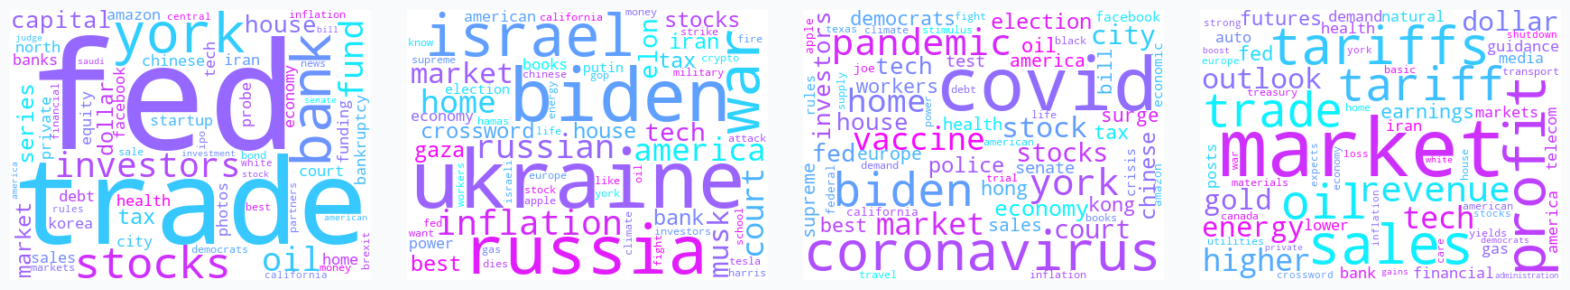

✓ Saved: lda_wordclouds_one_row.png (4 topics, tight spacing)


In [12]:
# ── Beautiful One-Row LDA Word Clouds (Tight Spacing) ───────────────
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.gridspec import GridSpec

# Extract top words for word clouds (richer set)
def get_topic_terms(model, feature_names, n_top=60):
    """Return dict: topic_id → {word: weight} for WordCloud"""
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[:-n_top-1:-1]
        topics[topic_idx] = {feature_names[i]: topic[i] for i in top_idx}
    return topics

lda_cloud_terms = get_topic_terms(lda, vocab, n_top=60)

# ── Create one-row layout with TIGHT spacing ─────────────────────────
n_cols = N_TOPICS
fig = plt.figure(figsize=(5 * n_cols, 6), facecolor='#F8FAFC')

# 🔥 Tighter spacing: wspace=0.02 (reduced from 0.08)
gs = GridSpec(1, n_cols, figure=fig, wspace=0.1, hspace=0.1)

for tid in range(N_TOPICS):
    ax = fig.add_subplot(gs[0, tid])
    
    # Generate word cloud with cool colormap
    wc = WordCloud(width=400, height=300,
                   background_color='white',
                   colormap=plt.cm.cool,          # ← Your requested COOL colormap
                   contour_width=0,               # ← No border outline
                   max_words=80,
                   relative_scaling=0.5,
                   normalize_plurals=True,
                   random_state=42 + tid,
                   min_font_size=8)
    
    wc.generate_from_frequencies(lda_cloud_terms[tid])
    
    # Display word cloud (no axes, no labels, no badges)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_axis_off()

# # Subtle overall title (optional)
# fig.suptitle('LDA Topic Word Clouds', 
#              fontsize=16, fontweight='bold', color='#1E293B',
#              y=0.98, fontfamily='sans-serif')

# Save at 300 DPI
plt.savefig('lda_wordclouds_one_row.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='#F8FAFC', 
            edgecolor='none')
plt.show()
print(f'✓ Saved: lda_wordclouds_one_row.png ({N_TOPICS} topics, tight spacing)')

---
## 5 · BERTopic (with NMF Fallback)

**Improvements:**
- `min_topic_size=30` (was 10) — more stable clusters with 3K docs
- Let BERTopic auto-discover topics, then reduce to `N_TOPICS`
- If BERTopic unavailable, NMF with `sublinear_tf` + bigram support serves as a strong fallback

In [ ]:
random.seed(time.time())
USE_BERTOPIC = False
bert_topics_for_cloud = {}

try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer

    print('Running BERTopic (this may take a few minutes)...')

    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

    bert_model = BERTopic(
        embedding_model=embedding_model,
        nr_topics=N_TOPICS,
        top_n_words=14,
        verbose=False,
        min_topic_size=30,           # more stable for 3K docs
        calculate_probabilities=False,
    )

    docs = df['clean_text'].tolist()
    topics, _ = bert_model.fit_transform(docs)

    topic_info = bert_model.get_topic_info()
    valid_topics = [t for t in topic_info['Topic'].tolist() if t != -1][:N_TOPICS]

    print(f'\n── BERTopic Topics ({len(valid_topics)} valid) ──')
    for tid in valid_topics:
        tw = bert_model.get_topic(tid)
        print(f'  Topic {tid}: {" | ".join(w for w, _ in tw[:10])}')

    bert_topics_for_cloud = {tid: bert_model.get_topic(tid) for tid in valid_topics}
    USE_BERTOPIC = True

except ImportError:
    print('BERTopic not installed — using NMF (TF-IDF) as neural topic analog.')
    print('To install: pip install bertopic sentence-transformers')

except Exception as e:
    print(f'BERTopic failed: {e}')
    print('Falling back to NMF.')

Running BERTopic (this may take a few minutes)...

── BERTopic Topics (3 valid) ──
  Topic 0: trump | china | market | biden | covid | home | fed | ukraine | york | russia
  Topic 1: trump | china | coronavirus | covid | york | fed | market | trade | biden | stocks
  Topic 2: trump | pepper | salt | quiz | china | news | america | trade | york | russia


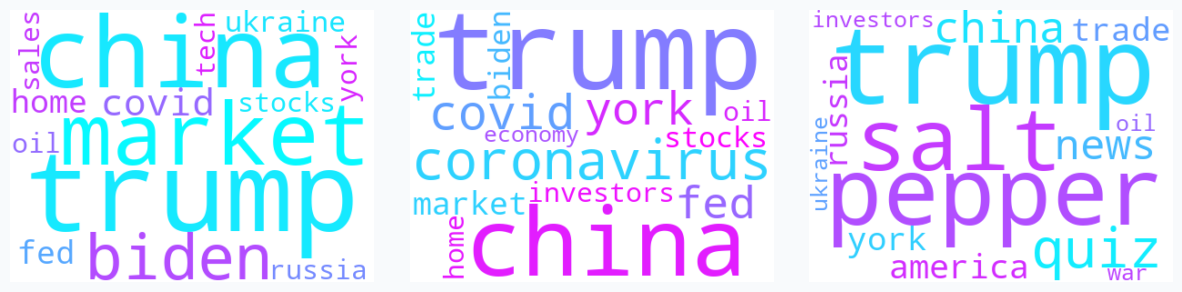

✓ Saved: bertopic_wordclouds_one_row.png (3 topics, tight spacing)


In [14]:
# ── Beautiful One-Row BERTopic Word Clouds ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.gridspec import GridSpec

# Only run if BERTopic succeeded
if USE_BERTOPIC and bert_topics_for_cloud:
    
    # ── Helper: Convert BERTopic format to WordCloud format ──
    def bertopic_to_wordcloud_dict(topic_data):
        """Convert [(word, weight), ...] → {word: weight}"""
        return {word: weight for word, weight in topic_data}
    
    # Prepare topic data for word clouds
    bert_cloud_data = {
        tid: bertopic_to_wordcloud_dict(terms) 
        for tid, terms in bert_topics_for_cloud.items()
    }
    
    # Get sorted list of valid topic IDs for consistent ordering
    valid_tids = sorted(bert_cloud_data.keys())
    n_topics = len(valid_tids)
    
    # ── Create one-row layout with TIGHT spacing ─────────────────────
    fig = plt.figure(figsize=(5 * n_topics, 6), facecolor='#F8FAFC')
    
    # 🔥 Tight spacing: wspace=0.02 for seamless flow
    gs = GridSpec(1, n_topics, figure=fig, wspace=0.1, hspace=0.1)
    
    # Color cycle for potential future enhancements (kept for consistency)
    topic_colors = plt.cm.Set2(np.linspace(0, 1, max(n_topics, 8)))
    
    for idx, tid in enumerate(valid_tids):
        ax = fig.add_subplot(gs[0, idx])
        
        # Generate word cloud with cool colormap
        wc = WordCloud(width=400, height=300,
                       background_color='white',
                       colormap=plt.cm.cool,          # ← Your requested COOL colormap
                       contour_width=0,               # ← No border outline
                       max_words=80,
                       relative_scaling=0.5,
                       normalize_plurals=True,
                       random_state=42 + idx,         # Unique seed per topic
                       min_font_size=8)
        
        wc.generate_from_frequencies(bert_cloud_data[tid])
        
        # Display: pure word cloud, no axes, no labels, no badges
        ax.imshow(wc, interpolation='bilinear')
        ax.set_axis_off()
    
    # # Subtle overall title (optional — comment out for pure clouds)
    # fig.suptitle('BERTopic: Semantic Word Clouds', 
    #              fontsize=16, fontweight='bold', color='#1E293B',
    #              y=0.98, fontfamily='sans-serif')
    
    # Save at 300 DPI — print-ready quality
    plt.savefig('bertopic_wordclouds_one_row.png', 
                dpi=300, 
                bbox_inches='tight',
                facecolor='#F8FAFC', 
                edgecolor='none')
    plt.show()
    print(f'✓ Saved: bertopic_wordclouds_one_row.png ({n_topics} topics, tight spacing)')

else:
    # Fallback message if BERTopic wasn't used
    print('⚠️  BERTopic visualization skipped.')
    print('   → Set USE_BERTOPIC = True and ensure bertopic + sentence-transformers are installed')
    print('   → Or install with: pip install bertopic sentence-transformers')

---
## Signal Map Feature Extraction

This is the core output: for each day, count how many times each signal category's keywords appear in the raw (lowercase) headline text. The result is a date-indexed DataFrame with one column per signal category — ready to merge with price/returns data for modeling.

**Design notes:**
- We match on **raw lowercase text** (not cleaned text) because signals like `rate cut`, `trade war` need their full bigram form
- Regex word boundaries (`\b`) prevent partial matches (e.g., `war` won't match `warning`)
- Multi-word phrases are matched as exact sequences
- Counts are additive: if a day has `tariff` appearing 5 times + `trade war` 2 times → `TRADE_WAR = 7`

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SIGNAL MAP — keyword sets for each thematic category
# Informed by LDA/NMF/BERTopic results + domain knowledge
# ─────────────────────────────────────────────────────────────────────────────

signal_map = {
    # ── TRADE & TARIFFS ──
    'TRADE_WAR': {
        'tariff', 'tariffs', 'trade war', 'trade deal', 'trade talks',
        'tariff pause', 'retaliatory', 'duties', 'ban', 'blacklist',
        'reshoring', 'import tax', 'export controls', 'trade deficit',
        'trade surplus', 'sanctions',
    },

    # ── FEDERAL RESERVE & MONETARY POLICY ──
    'FED_POLICY': {
        'rate cut', 'rate cuts', 'rate hike', 'rate hikes',
        'cuts rates', 'raises rates', 'holds rates',
        'rate cut hopes', 'dovish', 'hawkish', 'pivot', 'easing',
        'tightening', 'soft landing', 'pause', 'fed funds',
        'quantitative', 'tapering', 'inflation target',
        'federal reserve', 'powell', 'fomc',
    },

    # ── FEAR & CRISIS ──
    'FEAR_CRISIS': {
        'crash', 'recession', 'crisis', 'plunge', 'collapse', 'sell-off',
        'selloff', 'contagion', 'default', 'bank run', 'meltdown',
        'bubble', 'shutdown', 'tumble', 'plummet', 'panic', 'volatility',
        'stocks fall', 'shares plunge', 'bear market', 'downturn',
        'liquidity crisis', 'systemic risk', 'debt ceiling',
    },

    # ── EARNINGS & CORPORATE RESULTS ──
    'EARNINGS': {
        'earnings beat', 'beat expectations', 'revenue beat',
        'raised guidance', 'blowout', 'upgrade', 'strong demand',
        'sales growth', 'profit growth', 'earnings miss',
        'missed expectations', 'revenue miss', 'lowered guidance',
        'downgrade', 'weak demand', 'earnings surprise',
        'quarterly results', 'profit warning',
    },

    # ── EUPHORIA & MOMENTUM ──
    'EUPHORIA_MOMENTUM': {
        'surge', 'rally', 'boom', 'record high', 'all-time high', 'soar',
        'breakout', 'bull market', 'outperform', 'recovery', 'rebound',
        'inflows', 'stocks rise', 'shares jump', 'market rally',
    },

    # ── GEOPOLITICAL ──
    'GEOPOLITICAL': {
        'ceasefire', 'peace talks', 'peace',
        'war', 'invasion', 'missile', 'drone', 'airstrike', 'nuclear',
        'strait of hormuz', 'houthi', 'red sea', 'regime change',
        'retaliation', 'escalation', 'proxy war', 'coup', 'intercept',
        'ukraine war', 'strikes', 'nato', 'gaza', 'iran',
        'military', 'troops', 'pentagon', 'defense',
    },

    # ── SECTOR TRIGGERS ──
    'SECTOR_TRIGGER': {
        'fda approval', 'buyback', 'merger', 'acquisition', 'ipo',
        'billion buyback', 'share buyback', 'spinoff', 'spin-off',
        'takeover', 'antitrust', 'monopoly', 'breakup',
    },

    # ── ENERGY & COMMODITIES ──
    'ENERGY_COMMODITY': {
        'oil spike', 'shortage', 'opec', 'oil', 'production cut',
        'gold', 'commodity', 'supply chain', 'natural gas', 'pipeline',
        'refinery', 'shipping', 'suez canal', 'copper', 'crude',
        'brent', 'wti', 'lng', 'solar', 'renewable',
    },

    # ── LABOR & CONSUMER ──
    'LABOR_CONSUMER': {
        'hiring', 'consumer confidence', 'retail sales', 'wages',
        'consumer sentiment', 'unemployment', 'jobless', 'payrolls',
        'labor market', 'job openings', 'layoffs', 'workforce',
        'consumer spending', 'housing starts', 'mortgage',
    },

    # ── TRUMP & POLICY ──
    'TRUMP_POLICY': {
        'deregulation', 'tax cut', 'tax cuts', 'infrastructure',
        'trump announces', 'blocks trump', 'executive order',
        'trump tariff', 'trump policy', 'trump trade',
    },

    # ── CRYPTO & FINTECH ──
    'CRYPTO_FINTECH': {
        'bitcoin', 'crypto', 'cryptocurrency', 'blockchain', 'stablecoin',
        'digital currency', 'meme stock', 'short squeeze',
        'magnificent seven', 'coinbase', 'ethereum', 'defi', 'nft',
        'crypto exchange', 'spot etf',
    },

    # ── AMPLIFIER / MODIFIER ──
    'AMPLIFIER_MOD': {
        'eases', 'worst since', 'fears', 'concerns', 'deepens',
        'unprecedented', 'fears of', 'at risk', 'warns of', 'threat',
        'unexpected', 'surprise', 'biggest', 'historic',
        'despite', 'amid', 'growing concerns', 'mounting pressure',
    },

    # ── TECH & AI ── (new: emerged strongly in topic models)
    'TECH_AI': {
        'artificial intelligence', 'chatgpt', 'openai', 'nvidia',
        'chip', 'chips', 'semiconductor', 'tech stocks', 'big tech',
        'apple', 'google', 'microsoft', 'amazon', 'meta',
        'cloud computing', 'data center', 'machine learning',
    },
}

print(f'Signal categories: {len(signal_map)}')
for cat, keywords in signal_map.items():
    print(f'  {cat:25s} → {len(keywords):3d} keywords')

Signal categories: 13
  TRADE_WAR                 →  16 keywords
  FED_POLICY                →  22 keywords
  FEAR_CRISIS               →  24 keywords
  EARNINGS                  →  18 keywords
  EUPHORIA_MOMENTUM         →  15 keywords
  GEOPOLITICAL              →  27 keywords
  SECTOR_TRIGGER            →  13 keywords
  ENERGY_COMMODITY          →  20 keywords
  LABOR_CONSUMER            →  15 keywords
  TRUMP_POLICY              →  10 keywords
  CRYPTO_FINTECH            →  15 keywords
  AMPLIFIER_MOD             →  18 keywords
  TECH_AI                   →  17 keywords


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Build compiled regex patterns for each category (once)
# ─────────────────────────────────────────────────────────────────────────────

def build_signal_patterns(signal_map):
    """
    Compile regex patterns for each signal category.
    - Sort keywords longest-first so multi-word phrases match before substrings
    - Use word boundaries to avoid partial matches
    """
    patterns = {}
    for category, keywords in signal_map.items():
        # Sort by length descending so 'trade war' matches before 'trade'
        sorted_kw = sorted(keywords, key=len, reverse=True)
        # Escape special chars and join with OR
        escaped = [re.escape(kw) for kw in sorted_kw]
        pattern = r'\b(?:' + '|'.join(escaped) + r')\b'
        patterns[category] = re.compile(pattern, re.IGNORECASE)
    return patterns


signal_patterns = build_signal_patterns(signal_map)
print(f'Compiled {len(signal_patterns)} regex patterns.')

Compiled 13 regex patterns.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Count signal hits per day
# ─────────────────────────────────────────────────────────────────────────────

def count_signals(text, patterns):
    """Count total keyword matches per category in a text string."""
    return {cat: len(pat.findall(text)) for cat, pat in patterns.items()}


# Apply to each daily corpus (raw lowercase, not cleaned — preserves bigrams)
signal_counts = df['corpus_lower'].apply(lambda x: count_signals(x, signal_patterns))
signal_df = pd.DataFrame(signal_counts.tolist(), index=df.index)

print(f'Signal features shape: {signal_df.shape}')
print(f'\nTotal hits per category across all days:')
print(signal_df.sum().sort_values(ascending=False).to_string())

Signal features shape: (2992, 13)

Total hits per category across all days:
GEOPOLITICAL         13758
AMPLIFIER_MOD         8950
TECH_AI               8540
ENERGY_COMMODITY      8173
TRADE_WAR             5676
FEAR_CRISIS           5323
EUPHORIA_MOMENTUM     4405
SECTOR_TRIGGER        3221
LABOR_CONSUMER        2911
FED_POLICY            2715
CRYPTO_FINTECH        2420
TRUMP_POLICY           918
EARNINGS               588


In [18]:
# ── Quick sanity check: summary stats ──
print('\n── Signal Feature Summary Statistics ──')
print(signal_df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())


── Signal Feature Summary Statistics ──
                    mean    std    min    50%     max
TRADE_WAR         1.9000 3.0100 0.0000 1.0000 50.0000
FED_POLICY        0.9100 1.4700 0.0000 0.0000 12.0000
FEAR_CRISIS       1.7800 1.8800 0.0000 1.0000 16.0000
EARNINGS          0.2000 0.5200 0.0000 0.0000  5.0000
EUPHORIA_MOMENTUM 1.4700 1.4800 0.0000 1.0000  9.0000
GEOPOLITICAL      4.6000 3.9000 0.0000 4.0000 45.0000
SECTOR_TRIGGER    1.0800 1.3300 0.0000 1.0000 10.0000
ENERGY_COMMODITY  2.7300 2.5500 0.0000 2.0000 16.0000
LABOR_CONSUMER    0.9700 1.2200 0.0000 1.0000 12.0000
TRUMP_POLICY      0.3100 0.6700 0.0000 0.0000  7.0000
CRYPTO_FINTECH    0.8100 1.2700 0.0000 0.0000 11.0000
AMPLIFIER_MOD     2.9900 2.3800 0.0000 3.0000 17.0000
TECH_AI           2.8500 2.5300 0.0000 2.0000 18.0000


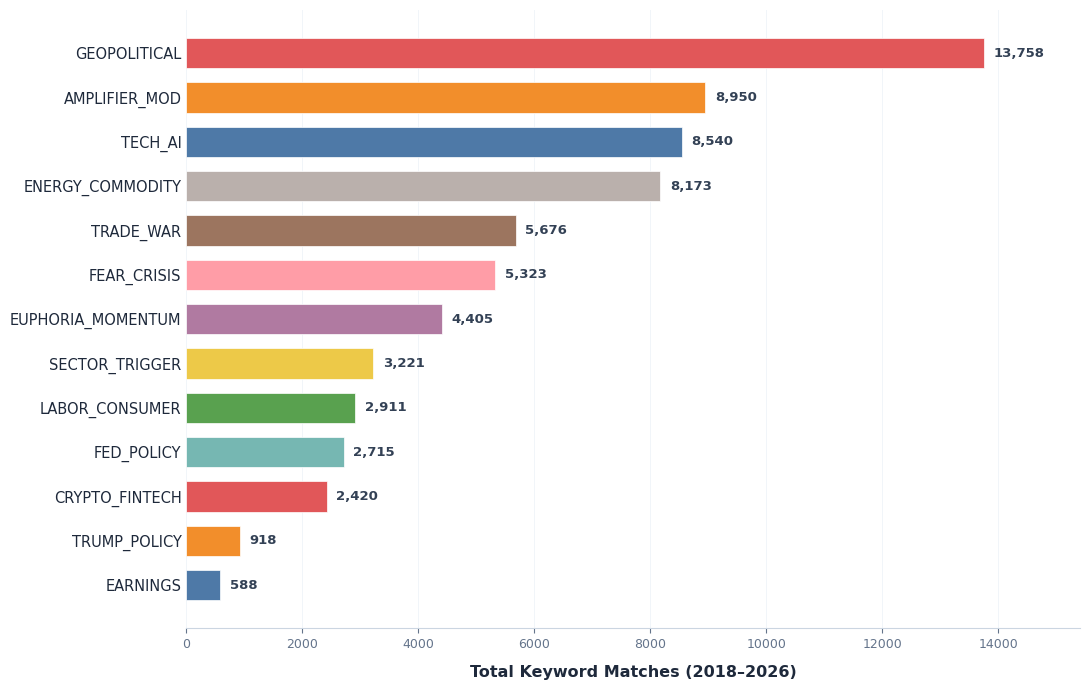

Saved: 08_signal_totals.png


In [19]:
# ── Tableau Classic 10 palette ──────────────────────────────────────
TABLEAU_10 = [
    '#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F',
    '#EDC948', '#B07AA1', '#FF9DA7', '#9C755F', '#BAB0AC',
]

# ── Plot: Signal category totals ───────────────────────────────────
totals = signal_df.sum().sort_values(ascending=True)
n = len(totals)

# Cycle through Tableau palette
bar_colors = [TABLEAU_10[i % len(TABLEAU_10)] for i in range(n)]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(np.arange(n), totals.values, color=bar_colors,
               edgecolor='white', linewidth=0.5, height=0.68)

# Y-axis labels
ax.set_yticks(np.arange(n))
ax.set_yticklabels(totals.index, fontsize=10.5, color='#1E293B',
                   fontweight='medium')

# X-axis
ax.set_xlabel('Total Keyword Matches (2018–2026)', fontsize=11.5,
              fontweight='bold', color='#1E293B', labelpad=10)
ax.tick_params(axis='x', labelsize=9, colors='#64748B')

# # Title + subtitle
# ax.set_title('Signal Category — Total Hits Across All Days',
#              fontsize=15, fontweight='bold', color='#0F172A',
#              pad=18, loc='left')
# ax.text(0, 1.02, 'Aggregated keyword matches by financial signal category',
#         transform=ax.transAxes, fontsize=10, color='#64748B', style='italic')

# Spines — keep only bottom, thin gray
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CBD5E1')
ax.spines['bottom'].set_linewidth(0.8)

# Subtle vertical gridlines
ax.grid(axis='x', color='#F1F5F9', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0)

# Count labels at bar ends
max_val = totals.max()
for bar, val in zip(bars, totals.values):
    ax.text(bar.get_width() + max_val * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left',
            fontsize=9.5, fontweight='bold', color='#334155')

# Give breathing room on x-axis
ax.set_xlim(0, max_val * 1.12)

plt.tight_layout()
plt.savefig('08_signal_totals.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: 08_signal_totals.png')

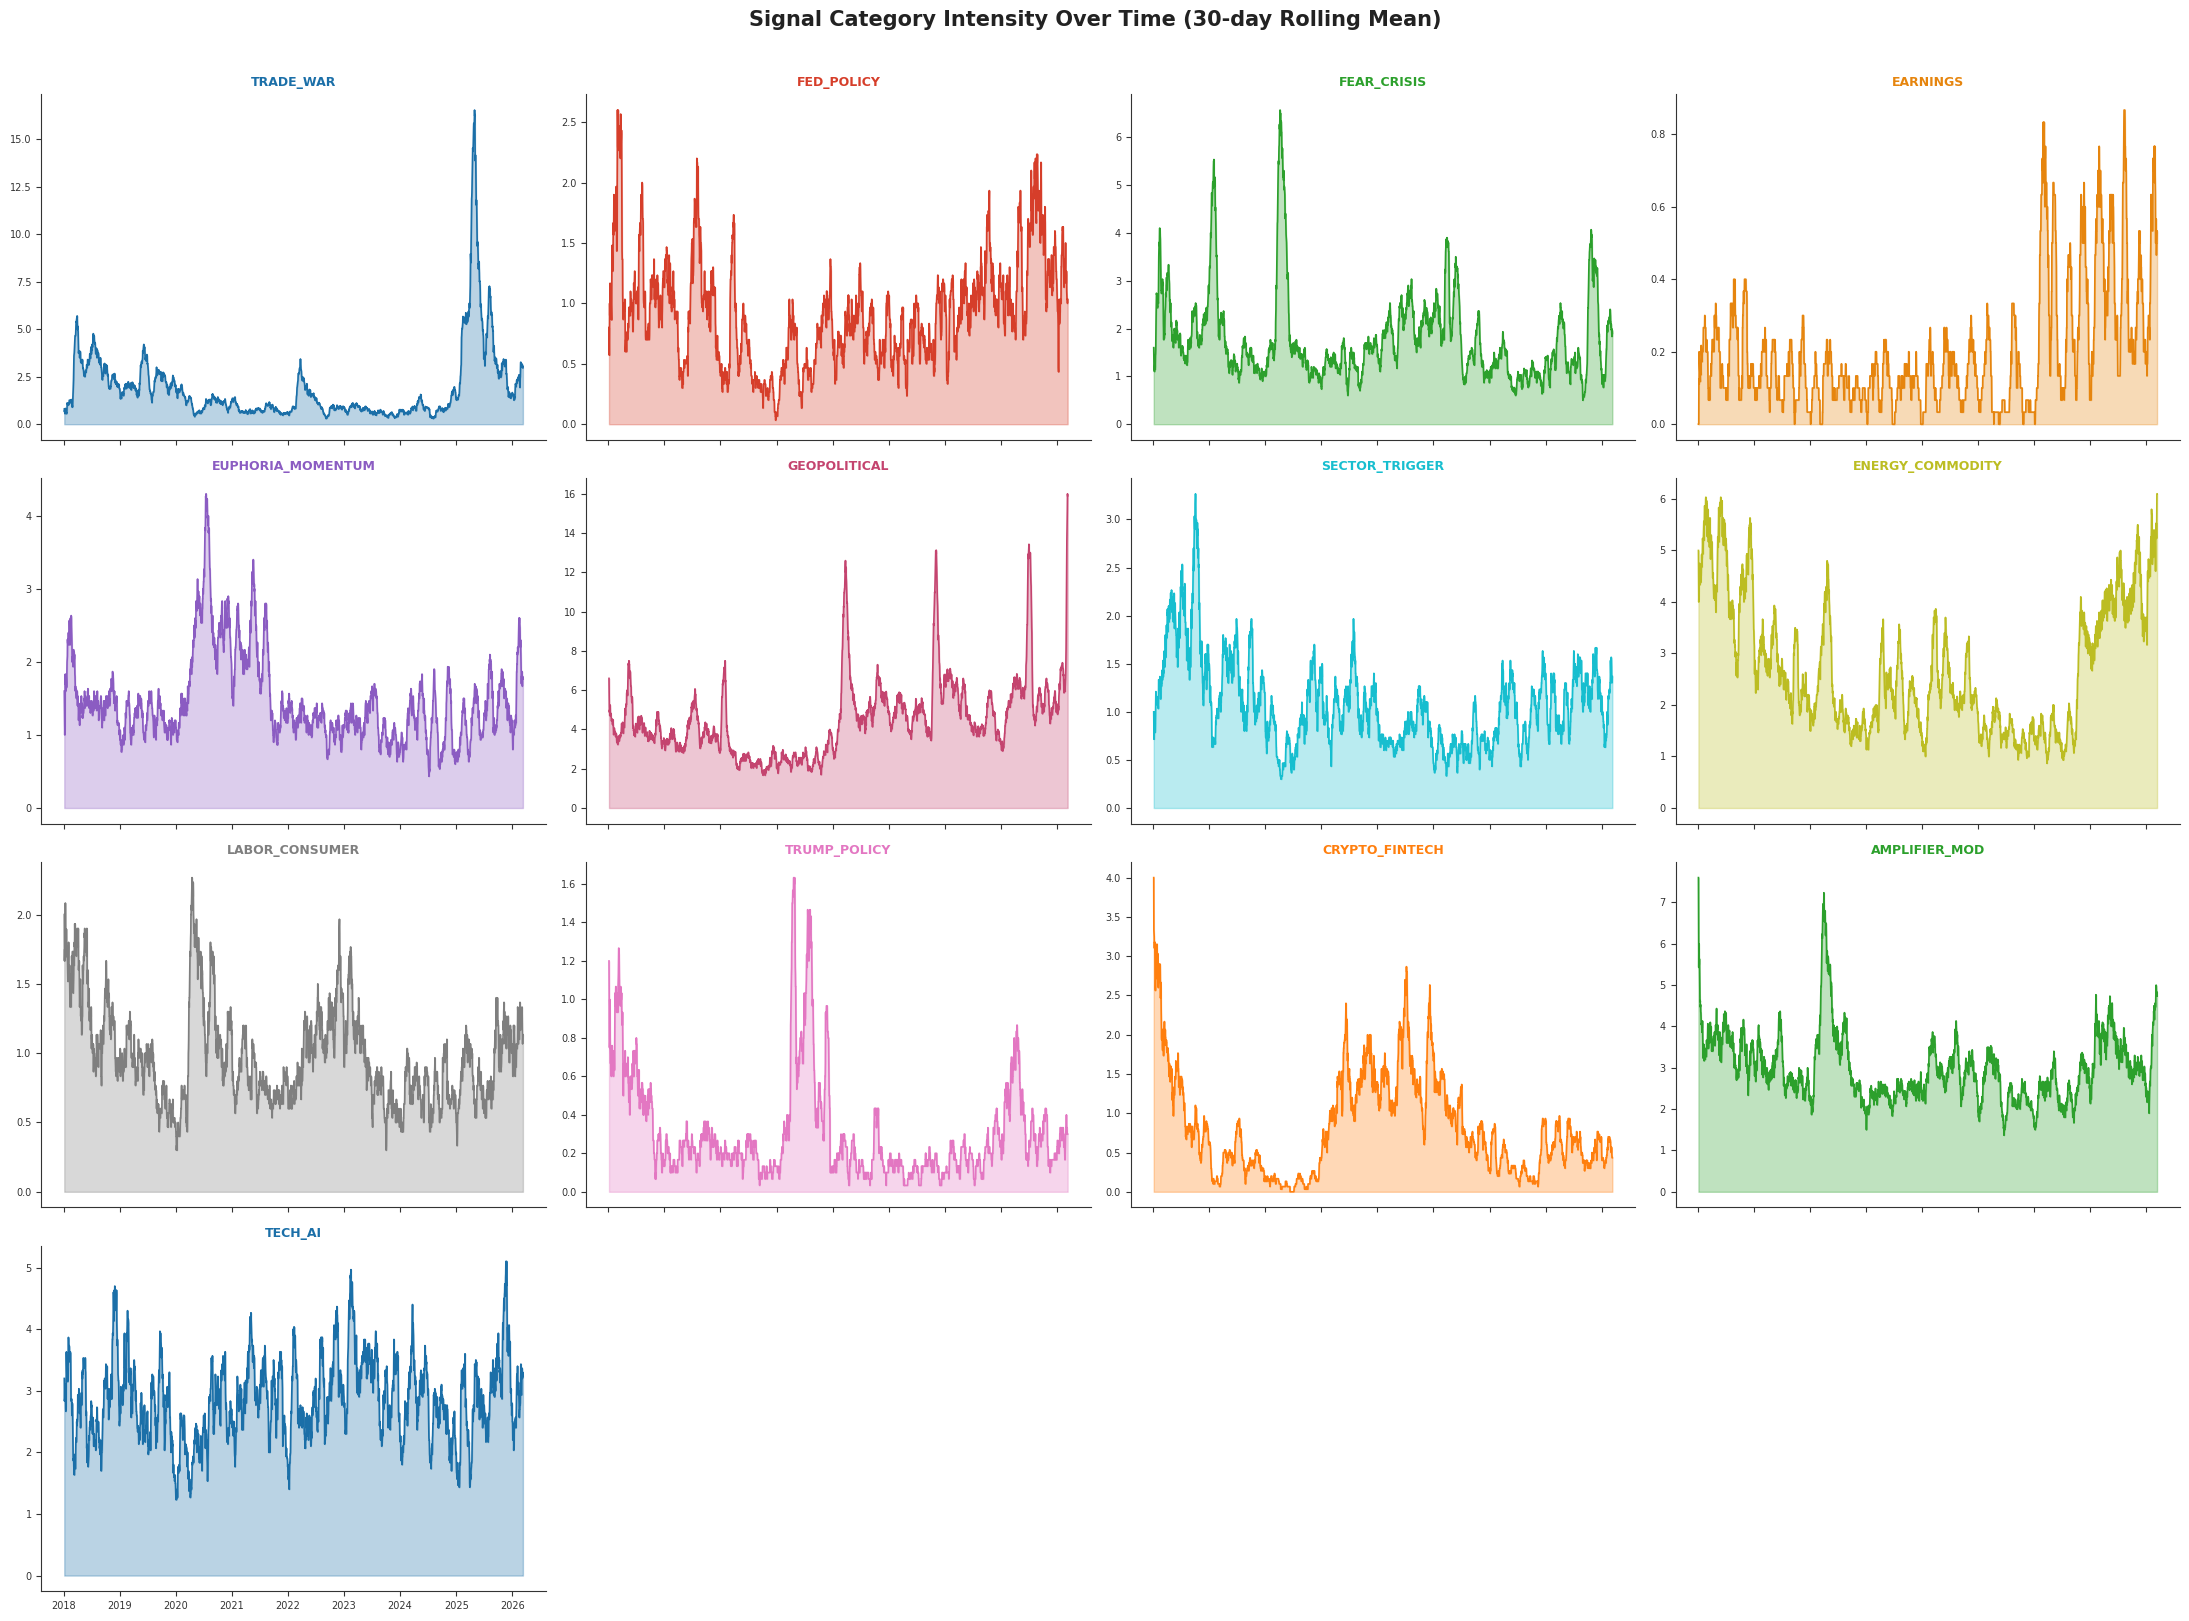

Saved: 09_signal_timeseries.png


In [20]:
# ── Plot: Signal time series (rolling 30-day mean) ──
fig, axes = plt.subplots(4, 4, figsize=(22, 16), sharex=True)
axes_flat = axes.flatten()

categories = signal_df.columns.tolist()

for idx, (ax, cat) in enumerate(zip(axes_flat, categories)):
    series = signal_df[cat]
    rolling = series.rolling(30, min_periods=5).mean()

    ax.fill_between(signal_df.index, rolling, alpha=0.3, color=PALETTE12[idx % len(PALETTE12)])
    ax.plot(signal_df.index, rolling, color=PALETTE12[idx % len(PALETTE12)], lw=1.2)
    ax.set_title(cat, fontsize=9, fontweight='bold', color=PALETTE12[idx % len(PALETTE12)])
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)

# Turn off unused
for ax in axes_flat[len(categories):]:
    ax.axis('off')

fig.suptitle('Signal Category Intensity Over Time (30-day Rolling Mean)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('09_signal_timeseries.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: 09_signal_timeseries.png')

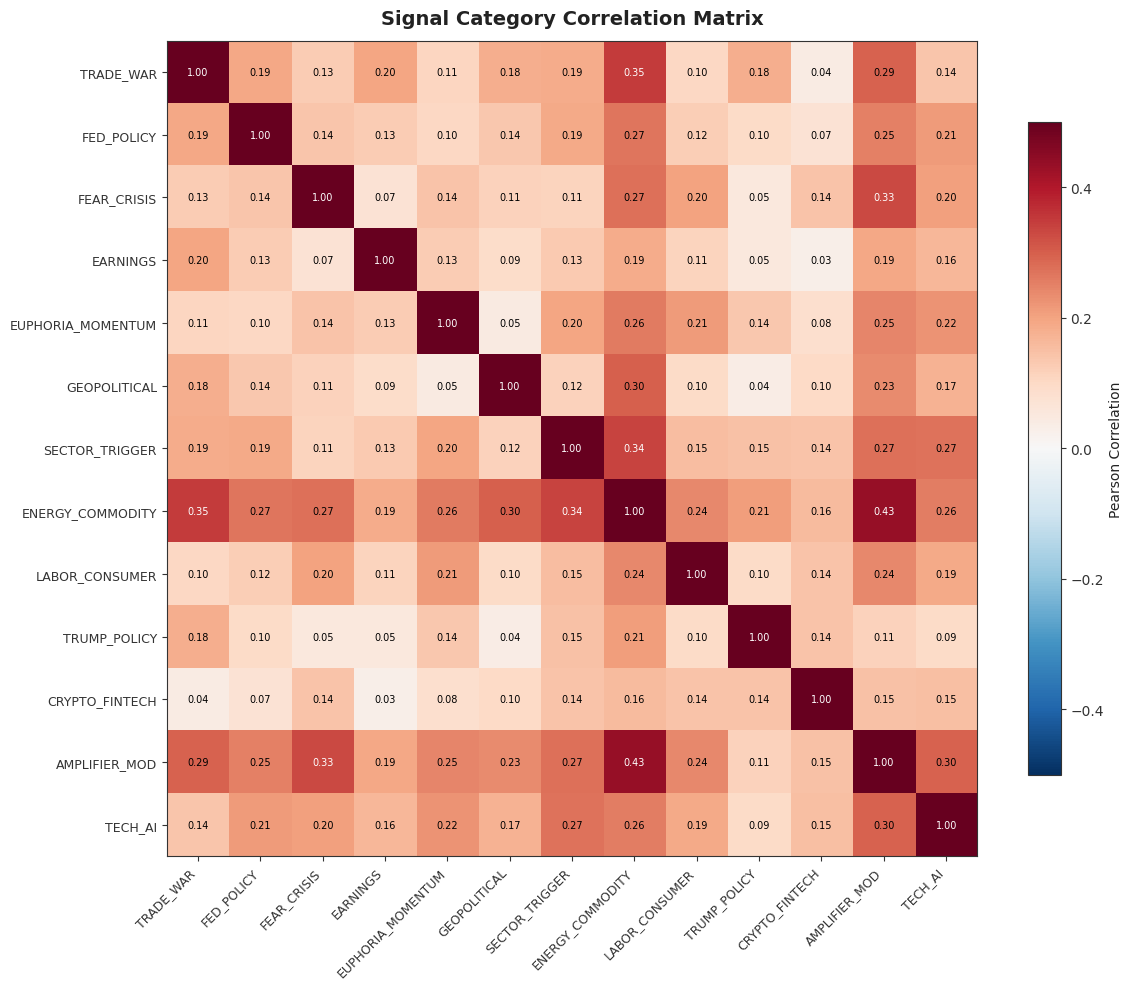

Saved: 10_signal_correlation.png


In [21]:
# ── Correlation heatmap between signal categories ──
corr = signal_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')

ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=9)
ax.set_title('Signal Category Correlation Matrix', fontsize=14, fontweight='bold', pad=12)

# Annotate cells
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.3 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson Correlation')
plt.tight_layout()
plt.savefig('10_signal_correlation.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: 10_signal_correlation.png')